# Task 2 - SeqScan clustering

Implementation of the SeqScan algorithm based on the pseudocode from page 16 of:

> Kalnis et al., *Discovering Stay Regions from Trajectories*, arXiv:1805.02102.

SeqScan is designed for trajectory clustering. Unlike standard DBSCAN, it respects the temporal order of points and can distinguish:

- stay regions,
- local noise inside a stay region,
- transition points between stay regions,
- non-consecutive stays in the same physical location.

The paper's pseudocode assumes an Incremental DBSCAN data structure. In this notebook I implement the same control flow with a simple DBSCAN recomputation after every insertion. This is slower, but it is easier to verify and is sufficient for small synthetic datasets.


## Imports and helpers


In [1]:
from dataclasses import dataclass
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN


In [2]:
@dataclass
class StayRegion:
    """One discovered SeqScan stay region."""
    region_id: int
    indices: list[int]
    start_index: int
    end_index: int
    start_time: float
    end_time: float
    center_x: float
    center_y: float
    size: int
    presence: float


def _dbscan_clusters(points: pd.DataFrame, indices: list[int], eps: float, min_pts: int) -> dict[int, list[int]]:
    """Run DBSCAN on selected global indices and return non-noise clusters."""
    if len(indices) < min_pts:
        return {}

    xy = points.loc[indices, ["x", "y"]].to_numpy()
    labels = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(xy)

    clusters: dict[int, list[int]] = {}
    for global_index, label in zip(indices, labels):
        if label != -1:
            clusters.setdefault(int(label), []).append(int(global_index))
    return {label: sorted(values) for label, values in clusters.items()}


def _presence(points: pd.DataFrame, indices: Iterable[int]) -> float:
    """
    Presence time of a possibly discontinuous region.

    For this sampled trajectory, presence is the sum of durations between consecutive
    trajectory points that both belong to the region. If sampling is uniform, this is
    equivalent to the number of consecutive in-region steps.
    """
    idx = sorted(set(int(i) for i in indices))
    if len(idx) <= 1:
        return 0.0

    times = points["t"].to_numpy()
    idx_set = set(idx)
    value = 0.0
    for i, j in zip(idx[:-1], idx[1:]):
        if j == i + 1 and i in idx_set and j in idx_set:
            value += float(times[j] - times[i])
    return value


def _candidate_stay_regions(points: pd.DataFrame, indices: list[int], eps: float, min_pts: int, min_presence: float) -> list[list[int]]:
    """Return DBSCAN clusters that satisfy SeqScan's duration/presence condition."""
    candidates = []
    for cluster_indices in _dbscan_clusters(points, indices, eps, min_pts).values():
        if len(cluster_indices) >= min_pts and _presence(points, cluster_indices) >= min_presence:
            candidates.append(cluster_indices)
    return candidates


def find_msr(points: pd.DataFrame, pool_indices: list[int], eps: float, min_pts: int, min_presence: float) -> Optional[list[int]]:
    """
    Find a minimal stay region (MSR) inside P.

    The pseudocode calls FindMSR(P) after inserting a point into P. Since P is processed
    online, the first qualifying DBSCAN cluster is the next MSR. When several candidates
    are visible, we choose the one that ends earliest in the trajectory, then starts earliest.
    """
    candidates = _candidate_stay_regions(points, pool_indices, eps, min_pts, min_presence)
    if not candidates:
        return None
    return min(candidates, key=lambda idx: (max(idx), min(idx), len(idx)))


def can_expand_active_region(points: pd.DataFrame, context_indices: list[int], active_indices: set[int],
                             new_index: int, eps: float, min_pts: int) -> bool:
    """
    Check whether the newly inserted point can be added to the active stay region.

    This replaces the Incremental DBSCAN reachability check in the paper. The new point
    can expand the active region if DBSCAN puts it into a non-noise component that already
    contains at least one active stay-region point.
    """
    if not active_indices or len(context_indices) < min_pts:
        return False

    clusters = _dbscan_clusters(points, context_indices, eps, min_pts)
    for cluster_indices in clusters.values():
        cluster_set = set(cluster_indices)
        if new_index in cluster_set and cluster_set.intersection(active_indices):
            return True
    return False


def _make_region(points: pd.DataFrame, region_id: int, indices: Iterable[int]) -> StayRegion:
    idx = sorted(set(int(i) for i in indices))
    region_points = points.loc[idx]
    return StayRegion(
        region_id=region_id,
        indices=idx,
        start_index=min(idx),
        end_index=max(idx),
        start_time=float(region_points["t"].min()),
        end_time=float(region_points["t"].max()),
        center_x=float(region_points["x"].mean()),
        center_y=float(region_points["y"].mean()),
        size=len(idx),
        presence=_presence(points, idx),
    )


## SeqScan implementation


In [3]:
def seqscan(points: pd.DataFrame, eps: float, min_pts: int, min_presence: float = 0.0) -> tuple[list[StayRegion], pd.DataFrame]:
    """
    SeqScan clustering following the page-16 pseudocode.

    Parameters
    ----------
    points:
        DataFrame with columns: t, x, y. Rows are processed in increasing time order.
    eps:
        DBSCAN spatial radius.
    min_pts:
        DBSCAN minimum number of points, equivalent to K in the paper.
    min_presence:
        Minimum stay-region presence duration, equivalent to delta in the paper.

    Returns
    -------
    stay_regions:
        Ordered list of discovered stay regions.
    labeled_points:
        Copy of input points with SeqScan labels.
    """
    points = points.sort_values("t").reset_index(drop=True).copy()
    points["seqscan_label"] = "transition"
    points["stay_region"] = -1

    C: list[int] = []  # context of the active stay region
    P: list[int] = []  # pool of points used to discover the next MSR
    active: set[int] = set()
    regions: list[StayRegion] = []

    for i in points.index:
        i = int(i)
        C.append(i)

        if can_expand_active_region(points, C, active, i, eps, min_pts):
            active.add(i)
            continue

        P.append(i)
        next_region = find_msr(points, P, eps, min_pts, min_presence)

        if next_region is not None:
            if active:
                regions.append(_make_region(points, len(regions), active))

            active = set(next_region)
            C = list(P)
            P = []

    if active:
        regions.append(_make_region(points, len(regions), active))

    # Label output points.
    for region in regions:
        points.loc[region.indices, "seqscan_label"] = "stay"
        points.loc[region.indices, "stay_region"] = region.region_id

    stay_spans = [(region.start_index, region.end_index) for region in regions]
    for idx, row in points.iterrows():
        if row["seqscan_label"] == "stay":
            continue
        inside_stay_span = any(start <= idx <= end for start, end in stay_spans)
        points.at[idx, "seqscan_label"] = "local_noise" if inside_stay_span else "transition"

    return regions, points


## Synthetic datasets

The paper's Figure 12 demonstrates cases where SeqScan differs from basic DBSCAN-like clustering:

1. clear linear sequence of stay regions with transition and local noise,
2. weak separation where consecutive stays can be spatially close,
3. non-consecutive stay regions that occupy the same physical places.

The following generator creates analogous toy trajectories. The `true_stage` column is not used by the algorithm; it is only for inspection.


In [4]:
def _normal_cluster(rng, center, n, scale=0.16, label="stay"):
    pts = rng.normal(loc=np.array(center), scale=scale, size=(n, 2))
    return [(float(x), float(y), label) for x, y in pts]


def _line_points(start, end, n, label="transition"):
    xs = np.linspace(start[0], end[0], n)
    ys = np.linspace(start[1], end[1], n)
    return [(float(x), float(y), label) for x, y in zip(xs, ys)]


def make_dataset_clear(seed=1):
    rng = np.random.default_rng(seed)
    rows = []
    rows += _normal_cluster(rng, (0.0, 0.0), 18, 0.14, "stay_A")
    rows += _normal_cluster(rng, (1.5, 1.0), 4, 0.10, "local_noise_A")
    rows += _normal_cluster(rng, (0.0, 0.0), 14, 0.14, "stay_A")
    rows += _line_points((0.8, 0.0), (5.0, 0.0), 6, "transition")
    rows += _normal_cluster(rng, (6.0, 0.0), 28, 0.16, "stay_B")
    rows += _line_points((6.5, 0.2), (8.6, 1.8), 5, "transition")
    rows += _normal_cluster(rng, (9.0, 2.0), 24, 0.16, "stay_C")
    return pd.DataFrame(rows, columns=["x", "y", "true_stage"]).assign(t=lambda df: np.arange(len(df)))


def make_dataset_weak_separation(seed=2):
    rng = np.random.default_rng(seed)
    rows = []
    rows += _normal_cluster(rng, (0.0, 0.0), 24, 0.14, "stay_A")
    rows += _line_points((0.5, 0.0), (2.4, 0.1), 5, "transition")
    rows += _normal_cluster(rng, (3.0, 0.2), 12, 0.12, "stay_B_msr")
    rows += _normal_cluster(rng, (2.0, 0.1), 8, 0.12, "stay_B")
    rows += _normal_cluster(rng, (1.0, 0.0), 8, 0.12, "stay_B_near_A")
    rows += _line_points((1.0, 0.0), (4.8, 1.7), 5, "transition")
    rows += _normal_cluster(rng, (5.3, 2.0), 22, 0.14, "stay_C")
    return pd.DataFrame(rows, columns=["x", "y", "true_stage"]).assign(t=lambda df: np.arange(len(df)))


def make_dataset_revisited(seed=3):
    rng = np.random.default_rng(seed)
    rows = []
    rows += _normal_cluster(rng, (0.0, 0.0), 20, 0.14, "A_first")
    rows += _line_points((0.6, 0.1), (4.2, 0.0), 5, "transition")
    rows += _normal_cluster(rng, (5.0, 0.0), 20, 0.14, "B_first")
    rows += _line_points((4.4, -0.1), (0.6, 0.0), 5, "transition")
    rows += _normal_cluster(rng, (0.0, 0.0), 20, 0.14, "A_second")
    rows += _line_points((0.6, 0.0), (4.3, 0.0), 5, "transition")
    rows += _normal_cluster(rng, (5.0, 0.0), 20, 0.14, "B_second")
    return pd.DataFrame(rows, columns=["x", "y", "true_stage"]).assign(t=lambda df: np.arange(len(df)))

synthetic_datasets = {
    "clear_stays": make_dataset_clear(),
    "weak_separation": make_dataset_weak_separation(),
    "revisited_regions": make_dataset_revisited(),
}

for name, df in synthetic_datasets.items():
    print(name, df.shape)
    display(df.head())


clear_stays (99, 4)


,x,y,true_stage,t
0,0.048382,0.115027,stay_A,0
1,0.046261,-0.182442,stay_A,1
2,0.126750,0.062492,stay_A,2
3,-0.075173,0.081357,stay_A,3
4,0.051040,0.041179,stay_A,4


weak_separation (84, 4)


,x,y,true_stage,t
0,0.026467,-0.073185,stay_A,0
1,-0.057829,-0.341805,stay_A,1
2,0.251959,0.160183,stay_A,2
3,-0.045559,0.108333,stay_A,3
4,0.039369,-0.077535,stay_A,4


revisited_regions (95, 4)


,x,y,true_stage,t
0,0.285729,-0.357793,A_first,0
1,0.058534,-0.079488,A_first,1
2,-0.063371,-0.030184,A_first,2
3,-0.282798,-0.032471,A_first,3
4,-0.121130,0.465220,A_first,4


## Run SeqScan on the synthetic data


In [5]:
EPS = 0.55
MIN_PTS = 8
MIN_PRESENCE = 0.0

results = {}
for name, df in synthetic_datasets.items():
    regions, labeled = seqscan(df, eps=EPS, min_pts=MIN_PTS, min_presence=MIN_PRESENCE)
    results[name] = (regions, labeled)

    print(f"\n{name}: {len(regions)} stay regions")
    display(pd.DataFrame([region.__dict__ for region in regions]).drop(columns=["indices"]))
    display(labeled["seqscan_label"].value_counts().rename("count"))



clear_stays: 3 stay regions


,region_id,start_index,end_index,start_time,end_time,center_x,center_y,size,presence
0,0,0,36,0.0,36.0,0.031475,-0.005625,33,31.0
1,1,42,70,42.0,70.0,6.007168,0.001895,29,28.0
2,2,74,98,74.0,98.0,8.945509,1.990604,25,24.0


seqscan_label
stay           87
transition      8
local_noise     4
Name: count, dtype: int64


weak_separation: 3 stay regions


,region_id,start_index,end_index,start_time,end_time,center_x,center_y,size,presence
0,0,0,25,0.0,25.0,0.074537,-0.006928,26,25.0
1,1,28,59,28.0,59.0,2.204585,0.131330,28,25.0
2,2,62,83,62.0,83.0,5.322573,1.999229,22,21.0


seqscan_label
stay           76
transition      4
local_noise     4
Name: count, dtype: int64


revisited_regions: 4 stay regions


,region_id,start_index,end_index,start_time,end_time,center_x,center_y,size,presence
0,0,0,20,0.0,20.0,0.014092,0.008278,21,20.0
1,1,25,45,25.0,45.0,4.969839,-0.042925,21,20.0
2,2,49,70,49.0,70.0,0.047441,0.030824,22,21.0
3,3,75,94,75.0,94.0,5.037829,-0.030509,20,19.0


seqscan_label
stay          84
transition    11
Name: count, dtype: int64

In [6]:
# Basic tests for the synthetic examples.
expected_region_counts = {
    "clear_stays": 3,
    "weak_separation": 3,
    "revisited_regions": 4,
}

for name, expected in expected_region_counts.items():
    actual = len(results[name][0])
    assert actual == expected, f"{name}: expected {expected} regions, got {actual}"

# In the revisited dataset SeqScan should not merge non-consecutive visits to A and B.
revisited_regions, revisited_labeled = results["revisited_regions"]
centers = np.array([[r.center_x, r.center_y] for r in revisited_regions])
assert np.linalg.norm(centers[0] - centers[2]) < 0.5, "first and third regions should be the same physical place"
assert np.linalg.norm(centers[1] - centers[3]) < 0.5, "second and fourth regions should be the same physical place"
assert revisited_regions[0].region_id != revisited_regions[2].region_id
assert revisited_regions[1].region_id != revisited_regions[3].region_id

print("All SeqScan synthetic tests passed.")


All SeqScan synthetic tests passed.


## Visualization


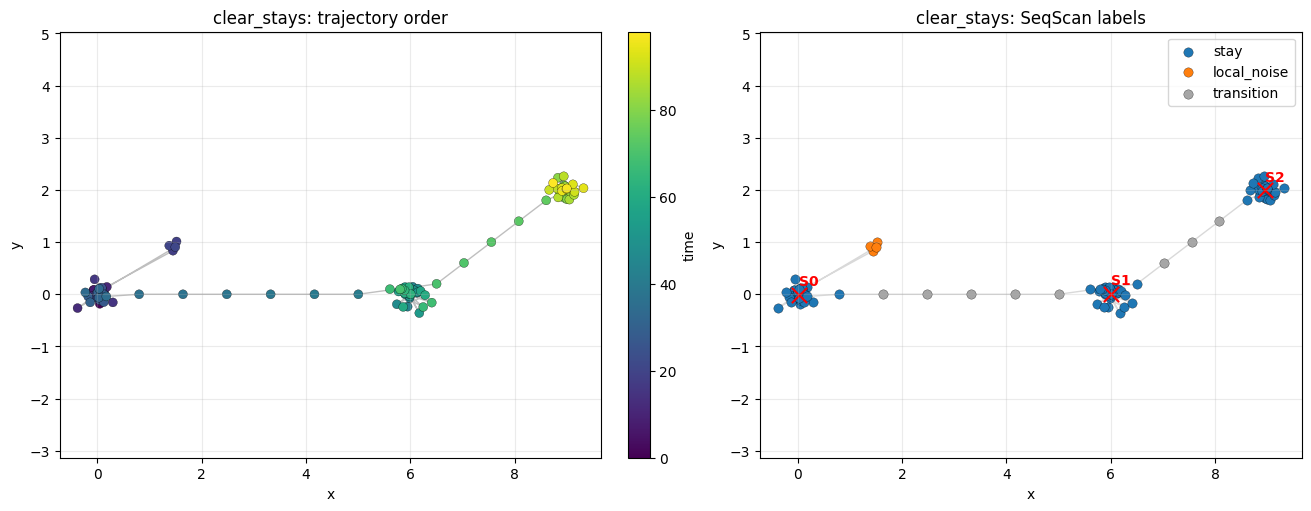

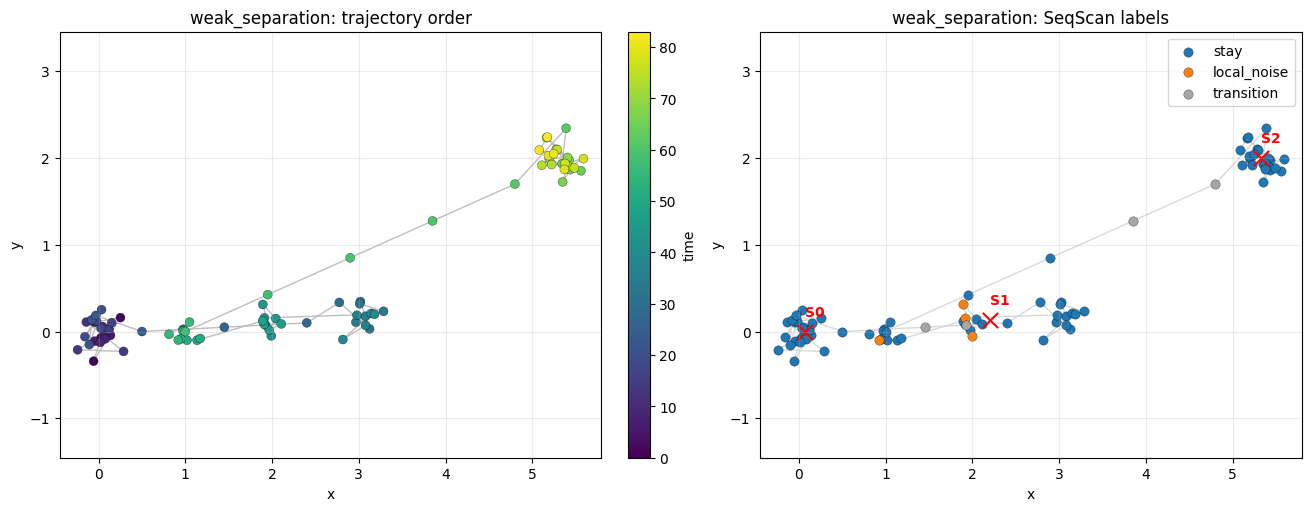

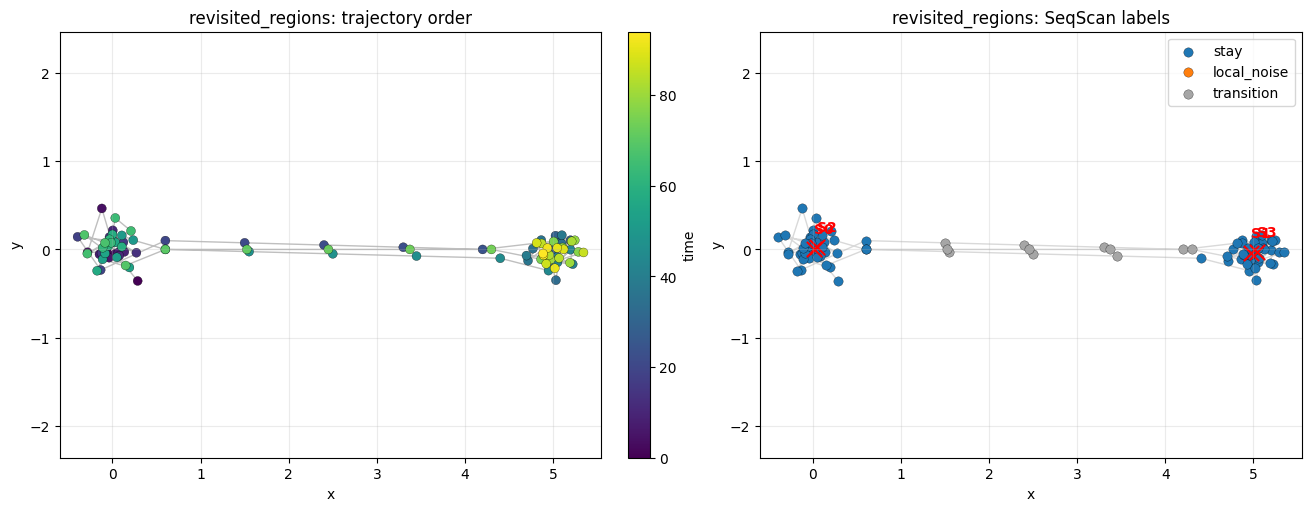

In [7]:
def plot_seqscan_result(name: str, df: pd.DataFrame, regions: list[StayRegion], labeled: pd.DataFrame):
    label_colors = {
        "stay": "tab:blue",
        "local_noise": "tab:orange",
        "transition": "0.65",
    }

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    sc = axes[0].scatter(df["x"], df["y"], c=df["t"], cmap="viridis", s=42, edgecolor="black", linewidth=0.2)
    axes[0].plot(df["x"], df["y"], color="0.75", linewidth=1, zorder=0)
    axes[0].set_title(f"{name}: trajectory order")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    fig.colorbar(sc, ax=axes[0], label="time")

    for label, color in label_colors.items():
        subset = labeled[labeled["seqscan_label"] == label]
        axes[1].scatter(subset["x"], subset["y"], label=label, color=color, s=45, edgecolor="black", linewidth=0.2)

    for region in regions:
        axes[1].scatter(region.center_x, region.center_y, marker="x", color="red", s=120)
        axes[1].text(region.center_x, region.center_y + 0.18, f"S{region.region_id}", color="red", weight="bold")

    axes[1].plot(df["x"], df["y"], color="0.85", linewidth=1, zorder=0)
    axes[1].set_title(f"{name}: SeqScan labels")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].legend()

    for ax in axes:
        ax.set_aspect("equal", adjustable="datalim")
        ax.grid(alpha=0.25)
    plt.show()

for name, original_df in synthetic_datasets.items():
    regions, labeled = results[name]
    plot_seqscan_result(name, original_df, regions, labeled)


## Interpretation

The synthetic tests show the intended SeqScan behavior:

- `clear_stays` finds three ordered stay regions and marks sparse points between them as transitions. Points that occur during a stay but are not density-reachable from it are marked as local noise.
- `weak_separation` still separates consecutive stays using time order and the MSR mechanism, even though part of the second stay approaches the first stay spatially.
- `revisited_regions` returns four stay regions, not two, because non-consecutive visits to the same physical locations are intentionally kept as separate trajectory events.

This is the main difference from running one global DBSCAN over all points: global DBSCAN would tend to merge the first and second visits to the same coordinates, while SeqScan preserves temporal structure.


## Optional comparison with global DBSCAN


In [8]:
for name, df in synthetic_datasets.items():
    labels = DBSCAN(eps=EPS, min_samples=MIN_PTS).fit_predict(df[["x", "y"]])
    n_clusters = len(set(labels) - {-1})
    n_noise = int(np.sum(labels == -1))
    print(f"{name}: global DBSCAN clusters = {n_clusters}, global DBSCAN noise points = {n_noise}")

print("Notice especially revisited_regions: global DBSCAN merges the two visits to A and the two visits to B.")


clear_stays: global DBSCAN clusters = 3, global DBSCAN noise points = 12
weak_separation: global DBSCAN clusters = 2, global DBSCAN noise points = 1
revisited_regions: global DBSCAN clusters = 2, global DBSCAN noise points = 9
Notice especially revisited_regions: global DBSCAN merges the two visits to A and the two visits to B.
